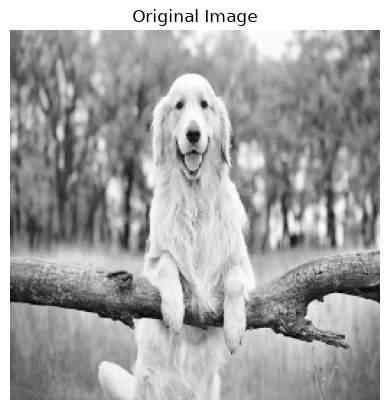

Image shape: (256, 256)


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(
    "../images/dog_grayscale.png",
    cv2.IMREAD_GRAYSCALE
)

N = 256
image = cv2.resize(image, (N, N))

plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

print("Image shape:", image.shape)

In [19]:
def hadamard_matrix(n):
    if n == 1:
        return np.array([[1]])

    H = hadamard_matrix(n // 2)

    return np.block([
        [H, H],
        [H, -H]
    ])

H = hadamard_matrix(N)
print("Hadamard Matrix Shape:", H.shape)
print(H[:4, :4])

Hadamard Matrix Shape: (256, 256)
[[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]


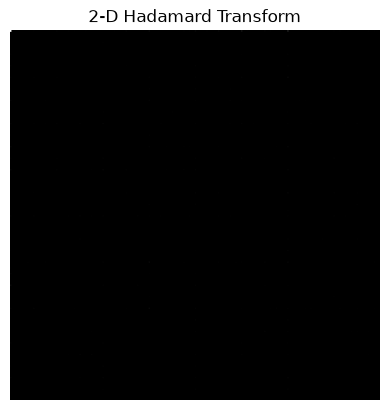

In [20]:
image_float = image.astype(np.float64)

hadamard_transform = H @ image_float @ H

hadamard_display = np.abs(hadamard_transform)

hadamard_display = (
    255 * hadamard_display / hadamard_display.max()
)

hadamard_display = np.uint8(hadamard_display)

plt.imshow(hadamard_display, cmap="gray")
plt.title("2-D Hadamard Transform")
plt.axis("off")
plt.show()

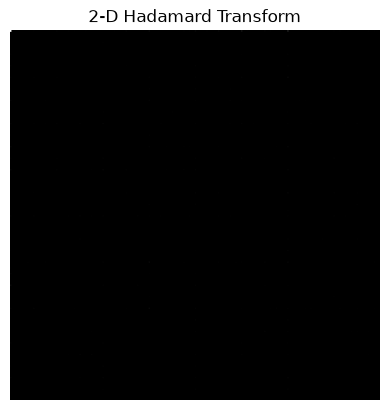

In [21]:
image_float = image.astype(np.float64)

hadamard_transform = H @ image_float @ H

hadamard_display = np.abs(hadamard_transform)

hadamard_display = (
    255 * hadamard_display / hadamard_display.max()
)

hadamard_display = np.uint8(hadamard_display)

plt.imshow(hadamard_display, cmap="gray")
plt.title("2-D Hadamard Transform")
plt.axis("off")
plt.show()

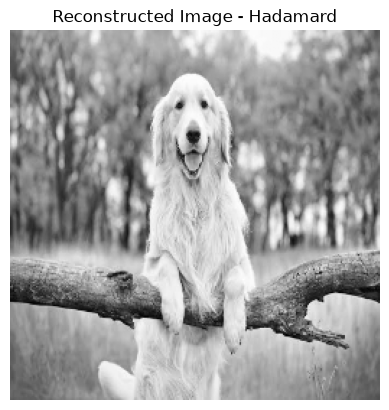

In [22]:
reconstructed_hadamard = (
    H @ hadamard_transform @ H
) / N**2

reconstructed_hadamard = np.clip(
    reconstructed_hadamard,
    0,
    255
).astype(np.uint8)

plt.imshow(reconstructed_hadamard, cmap="gray")
plt.title("Reconstructed Image - Hadamard")
plt.axis("off")
plt.show()

In [23]:
# Count sign changes in each row
def sign_changes(row):
    return np.sum(row[:-1] != row[1:])


# Calculate sequency of each Hadamard row
sequency = np.array([
    sign_changes(row)
    for row in H
])

order = np.argsort(sequency)

W = H[order]

print("Walsh Matrix Shape:", W.shape)
print(W[:4, :4])

Walsh Matrix Shape: (256, 256)
[[1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]]


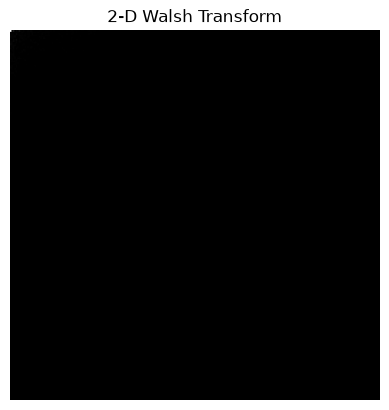

In [24]:
walsh_transform = W @ image_float @ W

walsh_display = np.abs(walsh_transform)

walsh_display = (
    255 * walsh_display / walsh_display.max()
)

walsh_display = np.uint8(walsh_display)

plt.imshow(walsh_display, cmap="gray")
plt.title("2-D Walsh Transform")
plt.axis("off")
plt.show()

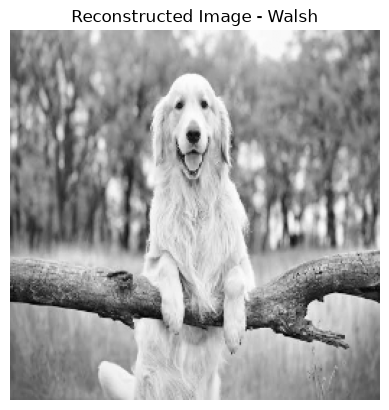

In [25]:
# Inverse Walsh Transform
reconstructed_walsh = (
    W @ walsh_transform @ W
) / N**2

reconstructed_walsh = np.clip(
    reconstructed_walsh,
    0,
    255
).astype(np.uint8)

plt.imshow(reconstructed_walsh, cmap="gray")
plt.title("Reconstructed Image - Walsh")
plt.axis("off")
plt.show()

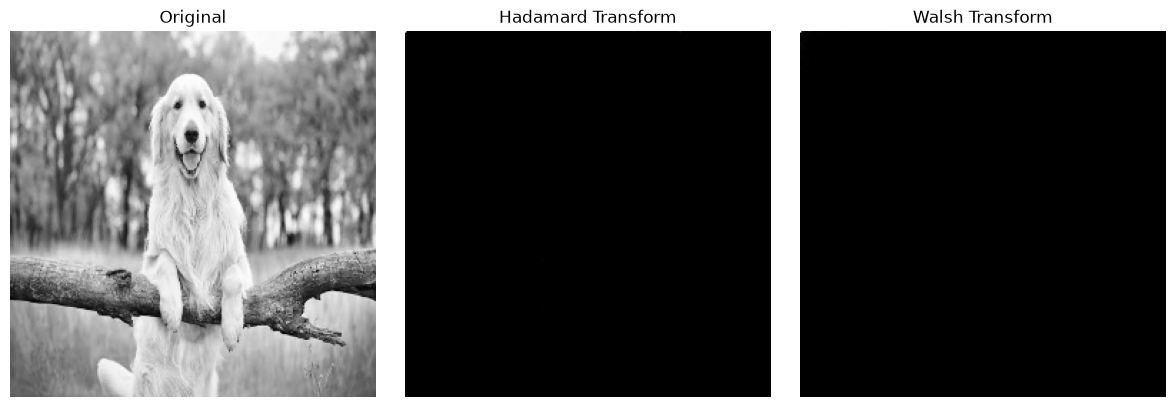

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(hadamard_display, cmap="gray")
plt.title("Hadamard Transform")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(walsh_display, cmap="gray")
plt.title("Walsh Transform")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
image_float = image.astype(np.float64)

dft = np.fft.fft2(image_float)

print("DFT Matrix Shape:", dft.shape)

print("\nFirst 5x5 DFT coefficients:")
print(dft[:5, :5])

DFT Matrix Shape: (256, 256)

First 5x5 DFT coefficients:
[[10162691.             +0.j         -1020677.3546754 +205137.18534025j
    136891.20302002  +7926.70689671j  -151499.35467441 +74113.95198687j
    -78481.25272466 +93958.05840616j]
 [  159281.10005427+180918.00848707j    21083.54327444 -74893.7504993j
   -257704.62342761 -58254.8551329j    -29847.39115959  -9104.02302566j
     20414.85888313-170342.00910624j]
 [  301773.1246361 -135953.20092242j  -133388.60677542+132006.18786867j
   -232412.61472371+112777.33207605j   -10496.3792375 +108736.4848405j
    108881.33040955-167131.53564317j]
 [   69260.98684847+186690.31442307j    56045.85286643-145871.7618772j
   -101004.93640619 -92290.33727596j   116808.00057179 -61013.5134448j
     68208.12392358 +95895.96983526j]
 [ -181406.86210422-114594.29167311j    40628.78346312-112089.44221405j
    116699.07321948+101544.57269521j   -20782.09621089 -30649.86439257j
     12097.35049714 +42682.17066839j]]


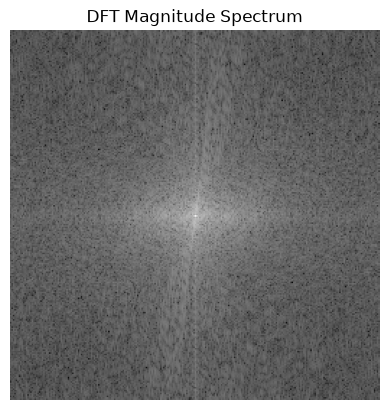

In [28]:
# Shift zero frequency to the center
dft_shifted = np.fft.fftshift(dft)

magnitude = np.abs(dft_shifted)

magnitude_spectrum = np.log(1 + magnitude)

plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("DFT Magnitude Spectrum")
plt.axis("off")
plt.show()

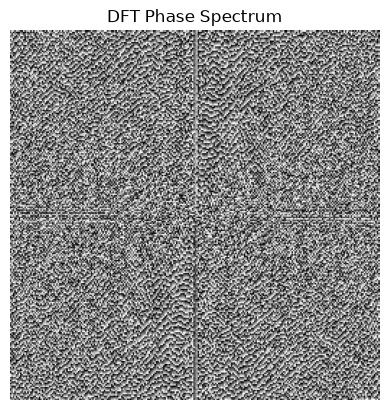

In [29]:
# Calculate phase
phase = np.angle(dft_shifted)

plt.imshow(phase, cmap="gray")
plt.title("DFT Phase Spectrum")
plt.axis("off")
plt.show()

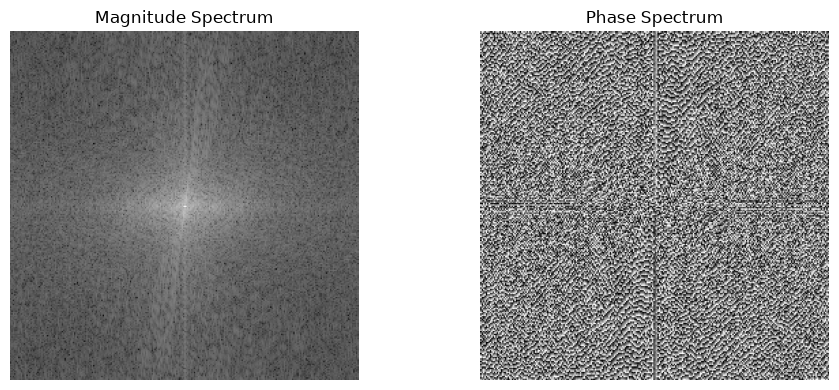

In [30]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(phase, cmap="gray")
plt.title("Phase Spectrum")
plt.axis("off")

plt.tight_layout()
plt.show()

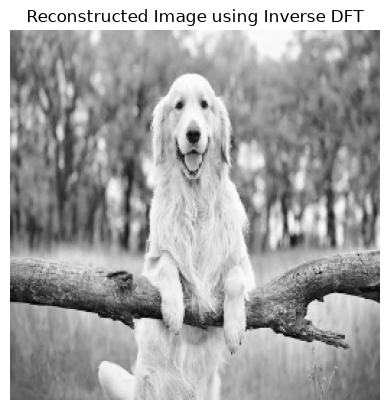

In [31]:
# Apply inverse DFT
reconstructed = np.fft.ifft2(dft)

# Take real part
reconstructed = np.real(reconstructed)

reconstructed = np.clip(
    reconstructed,
    0,
    255
).astype(np.uint8)

plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image using Inverse DFT")
plt.axis("off")
plt.show()

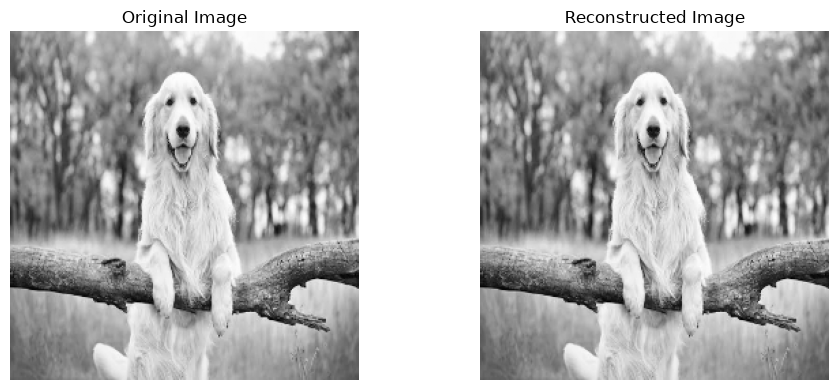

In [32]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

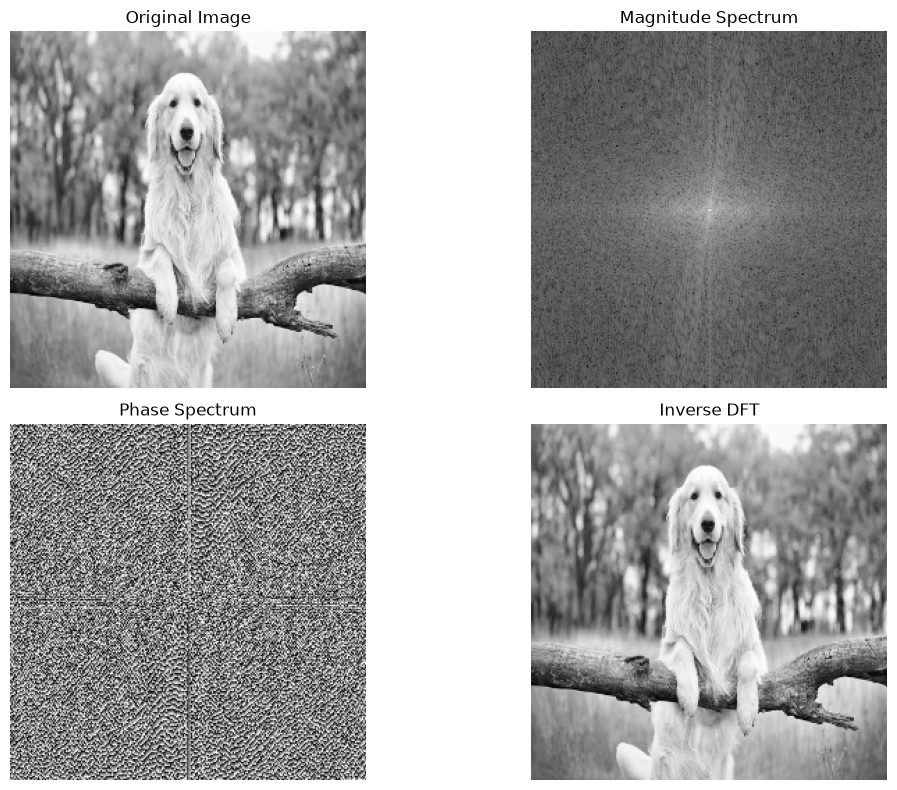

In [33]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(phase, cmap="gray")
plt.title("Phase Spectrum")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(reconstructed, cmap="gray")
plt.title("Inverse DFT")
plt.axis("off")

plt.tight_layout()
plt.show()